# Marketing Campaign Performance Analysis

## Project Overview

This project analyzes marketing campaign performance using Python.

The objective is to evaluate campaign effectiveness by analyzing important marketing metrics such as:

- Return on Investment (ROI)
- Click Through Rate (CTR)
- Cost Per Click (CPC)
- Conversion Rate

The project includes data cleaning, feature engineering, exploratory data analysis, visualization, and business insights.

## 1. Load the Dataset

The dataset is imported into the notebook using **Pandas** for analysis.

Before performing any analysis, the dataset is loaded and stored in a DataFrame. This enables efficient data manipulation, exploration, and visualization throughout the project.

In [5]:
from google.colab import files
uploaded = files.upload()

Saving marketing_campaign_dataset.xlsx to marketing_campaign_dataset.xlsx


## 2. Import Libraries
Import the Python libraries required for data manipulation, analysis, and visualization.

- **Pandas** is used for loading and manipulating datasets.
- **NumPy** supports numerical computations.
- **Matplotlib** is used to create charts and graphs.
- **Seaborn** enhances data visualization with attractive statistical plots.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## 3. Explore the Dataset

Before cleaning and analyzing the data, an initial exploration is performed to understand its structure.

This includes:
- Viewing the first few records.
- Checking the dataset dimensions.
- Identifying data types.
- Reviewing column names.
- Understanding the available variables for analysis.

In [7]:
df = pd.read_excel("marketing_campaign_dataset.xlsx")
df.head()

,Campaign_ID,Company,Campaign_Type,Target_Audience,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Date,Clicks,Impressions,Engagement_Score,Customer_Segment
0,1,Innovate Industries,Email,Men 18-24,30 days,Google Ads,0.04,16174,6.29,Chicago,2021-01-01 00:00:00,506,1922,6,Health & Wellness
1,2,NexGen Systems,Email,Women 35-44,60 days,Google Ads,0.12,11566,5.61,New York,2021-02-01 00:00:00,116,7523,7,Fashionistas
2,3,Alpha Innovations,Influencer,Men 25-34,30 days,YouTube,0.07,10200,7.18,Los Angeles,2021-03-01 00:00:00,584,7698,1,Outdoor Adventurers
3,4,DataTech Solutions,Display,All Ages,60 days,YouTube,0.11,12724,5.55,Miami,2021-04-01 00:00:00,217,1820,7,Health & Wellness
4,5,NexGen Systems,Email,Men 25-34,15 days,YouTube,0.05,16452,6.50,Los Angeles,2021-05-01 00:00:00,379,4201,3,Health & Wellness


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200005 entries, 0 to 200004
Data columns (total 15 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Campaign_ID       200005 non-null  int64  
 1   Company           200005 non-null  object 
 2   Campaign_Type     200005 non-null  object 
 3   Target_Audience   200005 non-null  object 
 4   Duration          200005 non-null  object 
 5   Channel_Used      200005 non-null  object 
 6   Conversion_Rate   200005 non-null  float64
 7   Acquisition_Cost  200005 non-null  int64  
 8   ROI               200005 non-null  float64
 9   Location          200005 non-null  object 
 10  Date              200005 non-null  object 
 11  Clicks            200005 non-null  int64  
 12  Impressions       200005 non-null  int64  
 13  Engagement_Score  200005 non-null  int64  
 14  Customer_Segment  200005 non-null  object 
dtypes: float64(2), int64(5), object(8)
memory usage: 22.9+ MB


In [9]:
df.columns

Index(['Campaign_ID', 'Company', 'Campaign_Type', 'Target_Audience',
       'Duration', 'Channel_Used', 'Conversion_Rate', 'Acquisition_Cost',
       'ROI', 'Location', 'Date', 'Clicks', 'Impressions', 'Engagement_Score',
       'Customer_Segment'],
      dtype='object')

In [10]:
df.shape

(200005, 15)

In [11]:
df.describe()

,Campaign_ID,Conversion_Rate,Acquisition_Cost,ROI,Clicks,Impressions,Engagement_Score
count,200005.000000,200005.000000,200005.000000,200005.000000,200005.000000,200005.000000,200005.000000
mean,100003.000000,0.080069,12504.441794,5.002416,549.774591,5507.307107,5.494673
std,57736.614632,0.040602,4337.663210,1.734485,260.019354,2596.863794,2.872593
min,1.000000,0.010000,5000.000000,2.000000,100.000000,1000.000000,1.000000
25%,50002.000000,0.050000,8740.000000,3.500000,325.000000,3266.000000,3.000000
50%,100003.000000,0.080000,12497.000000,5.010000,550.000000,5518.000000,5.000000
75%,150004.000000,0.120000,16264.000000,6.510000,775.000000,7753.000000,8.000000
max,200005.000000,0.150000,20000.000000,8.000000,1000.000000,10000.000000,10.000000


### Summary Statistics

The `describe()` function provides descriptive statistics for all numerical variables in the dataset.

From the summary:

- The dataset contains **200,005 marketing campaign records** with no missing numerical values.
- The average **conversion rate** is approximately **8%**.
- The average **acquisition cost** is about **12,504**.
- Campaigns generated an average of **550 clicks** and **5,507 impressions**.
- The average **ROI** is approximately **5**, indicating generally positive campaign performance.
- The average **engagement score** is **5.49** out of **10**, suggesting a moderate level of audience engagement.

In [12]:
df.isnull().sum()

,0
Campaign_ID,0
Company,0
Campaign_Type,0
Target_Audience,0
Duration,0
Channel_Used,0
Conversion_Rate,0
Acquisition_Cost,0
ROI,0
Location,0


### Missing Values

The dataset was checked for missing values to determine whether any observations required cleaning or imputation.

**Observation:** No missing values were found in the dataset, indicating that all variables are complete and ready for analysis.

## 5. Feature Engineering

Feature engineering involves creating new variables from existing data to provide additional insights into marketing campaign performance.

In this section:

- The **Date** column is converted into a datetime format.
- A **Month** column is created to support monthly trend analysis.
- **Acquisition Cost** is converted to a numeric format for calculations.
- **Click-Through Rate (CTR)** is calculated to measure the percentage of impressions that resulted in clicks.
- **Cost Per Click (CPC)** is calculated to determine the average cost incurred for each click.

In [13]:
# Convert the 'Date' column to datetime format
df['Date'] = pd.to_datetime(df['Date'], format='mixed')

# Create a new column containing the month
df['Month'] = df['Date'].dt.strftime('%b')

# Convert 'Acquisition_Cost' to numeric if necessary
if not pd.api.types.is_numeric_dtype(df['Acquisition_Cost']):
    df['Acquisition_Cost'] = (
        df['Acquisition_Cost']
        .str.replace(r'[\$,]', '', regex=True)
        .astype(float)
    )

# Create Click-Through Rate (CTR)
df['CTR'] = round((df['Clicks'] / df['Impressions']) * 100, 2)

# Create Cost Per Click (CPC)
df['CPC'] = round(df['Acquisition_Cost'] / df['Clicks'], 2)

# Preview the updated dataset
df.head()

,Campaign_ID,Company,Campaign_Type,Target_Audience,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Date,Clicks,Impressions,Engagement_Score,Customer_Segment,Month,CTR,CPC
0,1,Innovate Industries,Email,Men 18-24,30 days,Google Ads,0.04,16174,6.29,Chicago,2021-01-01,506,1922,6,Health & Wellness,Jan,26.33,31.96
1,2,NexGen Systems,Email,Women 35-44,60 days,Google Ads,0.12,11566,5.61,New York,2021-02-01,116,7523,7,Fashionistas,Feb,1.54,99.71
2,3,Alpha Innovations,Influencer,Men 25-34,30 days,YouTube,0.07,10200,7.18,Los Angeles,2021-03-01,584,7698,1,Outdoor Adventurers,Mar,7.59,17.47
3,4,DataTech Solutions,Display,All Ages,60 days,YouTube,0.11,12724,5.55,Miami,2021-04-01,217,1820,7,Health & Wellness,Apr,11.92,58.64
4,5,NexGen Systems,Email,Men 25-34,15 days,YouTube,0.05,16452,6.50,Los Angeles,2021-05-01,379,4201,3,Health & Wellness,May,9.02,43.41


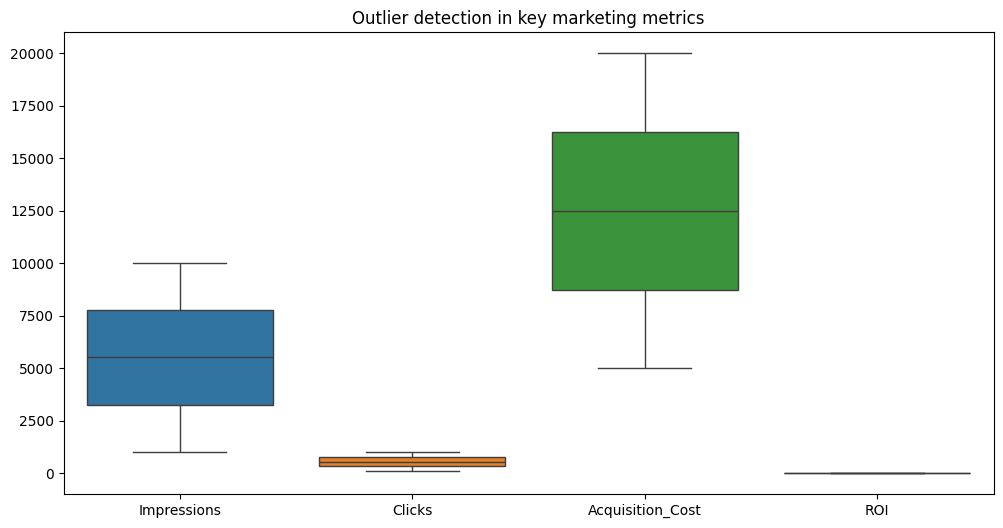

In [14]:
# Assuming 'Impressions' and 'Clicks' are available
# Replace 'Spend' and 'Conversions' with other numerical columns if needed
plt.figure(figsize=(12,6))
sns.boxplot(data=df[['Impressions', 'Clicks', 'Acquisition_Cost', 'ROI']])
plt.title("Outlier detection in key marketing metrics")
plt.show()

### Interpretation

Boxplots were used to identify potential outliers in the key marketing metrics: **Impressions, Clicks, Acquisition Cost, and ROI**.

The visualizations indicate that none of the variables contain significant outliers beyond the whiskers. This suggests that the dataset is relatively clean and does not contain extreme observations that could distort the analysis.

The median values indicate that a typical marketing campaign generated approximately **5,500 impressions**, **550 clicks**, incurred an **acquisition cost of about 12,500**, and achieved an **ROI of approximately 5**.

In [15]:
# Calculate performance metrics

# Click-Through Rate
df['CTR (%)'] = (df['Clicks'] / df['Impressions']) * 100

# Cost Per Click
df['CPC'] = df['Acquisition_Cost'] / df['Clicks']

# Convert Conversion Rate to percentage
df['Conversion Rate (%)'] = df['Conversion_Rate'] * 100

# Display selected metrics
df[['CTR (%)', 'CPC', 'Conversion Rate (%)', 'ROI']].head()

,CTR (%),CPC,Conversion Rate (%),ROI
0,26.326743,31.964427,4.0,6.29
1,1.541938,99.706897,12.0,5.61
2,7.586386,17.465753,7.0,7.18
3,11.923077,58.635945,11.0,5.55
4,9.021662,43.408971,5.0,6.50


## 5. Feature Engineering

Feature engineering was performed to create additional performance metrics that provide deeper insights into campaign effectiveness.

The following metrics were calculated:

- **Click-Through Rate (CTR):** Measures the percentage of impressions that resulted in clicks.
- **Cost Per Click (CPC):** Measures the average acquisition cost for each click.
- **Conversion Rate (%):** Converts the conversion rate from decimal format to percentage for easier interpretation.
- **Return on Investment (ROI):** The existing ROI values from the dataset were retained to evaluate campaign profitability.

In [16]:
# Convert the 'Date' column to datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Extract the full month name (e.g., January, February)
df['Month'] = df['Date'].dt.strftime('%B')

# Extract the month number to ensure months are sorted chronologically
df['Month_Num'] = df['Date'].dt.month

# Sort the dataset by month number
df = df.sort_values(by='Month_Num')

## 6. Date Preparation

To analyze campaign performance over time, the **Date** column was converted into a datetime format.

Two additional columns were created:

- **Month:** Stores the full month name (e.g., January, February) for reporting and visualization.
- **Month_Num:** Stores the numerical month (1–12) to ensure months appear in chronological order when creating charts.

Finally, the dataset was sorted by month number to improve the accuracy and readability of time-based visualizations.

In [17]:
df.head()

,Campaign_ID,Company,Campaign_Type,Target_Audience,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,...,Clicks,Impressions,Engagement_Score,Customer_Segment,Month,CTR,CPC,CTR (%),Conversion Rate (%),Month_Num
16,17,Innovate Industries,Display,Women 35-44,45 days,Website,0.08,5478,4.53,Houston,...,931,2488,3,Fashionistas,January,37.42,5.883996,37.419614,8.0,1
15,16,Innovate Industries,Social Media,Women 35-44,60 days,YouTube,0.11,9407,2.91,New York,...,299,1512,5,Health & Wellness,January,19.78,31.461538,19.775132,11.0,1
23,24,Innovate Industries,Email,Women 25-34,15 days,Facebook,0.04,17608,7.31,Miami,...,764,2157,8,Health & Wellness,January,35.42,23.047120,35.419564,4.0,1
22,23,NexGen Systems,Social Media,Women 35-44,15 days,YouTube,0.13,8699,2.12,Miami,...,646,3841,5,Health & Wellness,January,16.82,13.465944,16.818537,13.0,1
21,22,TechCorp,Influencer,All Ages,30 days,Facebook,0.02,12824,6.21,New York,...,319,8586,2,Foodies,January,3.72,40.200627,3.715351,2.0,1


/tmp/ipykernel_2009/1506721263.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(x='Month', y='ROI', data=df, ci=None, palette='coolwarm')
/tmp/ipykernel_2009/1506721263.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(x='Month', y='ROI', data=df, ci=None, palette='coolwarm')


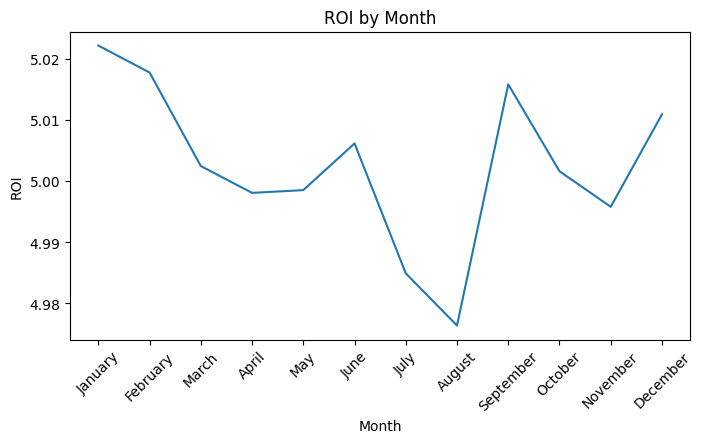

In [18]:
plt.figure(figsize=(8,4))
sns.lineplot(x='Month', y='ROI', data=df, ci=None, palette='coolwarm')
plt.title("ROI by Month")
plt.xticks(rotation=45)
plt.show()
plt.show()

## 7. Campaign Performance by Marketing Channel

This analysis compares the average performance of different marketing channels using three key performance indicators:

- **Return on Investment (ROI):** Measures campaign profitability.
- **Cost Per Click (CPC):** Measures the average cost incurred for each click.
- **Click-Through Rate (CTR):** Measures the percentage of impressions that resulted in clicks.

Comparing these metrics helps identify which marketing channels deliver the best overall campaign performance.

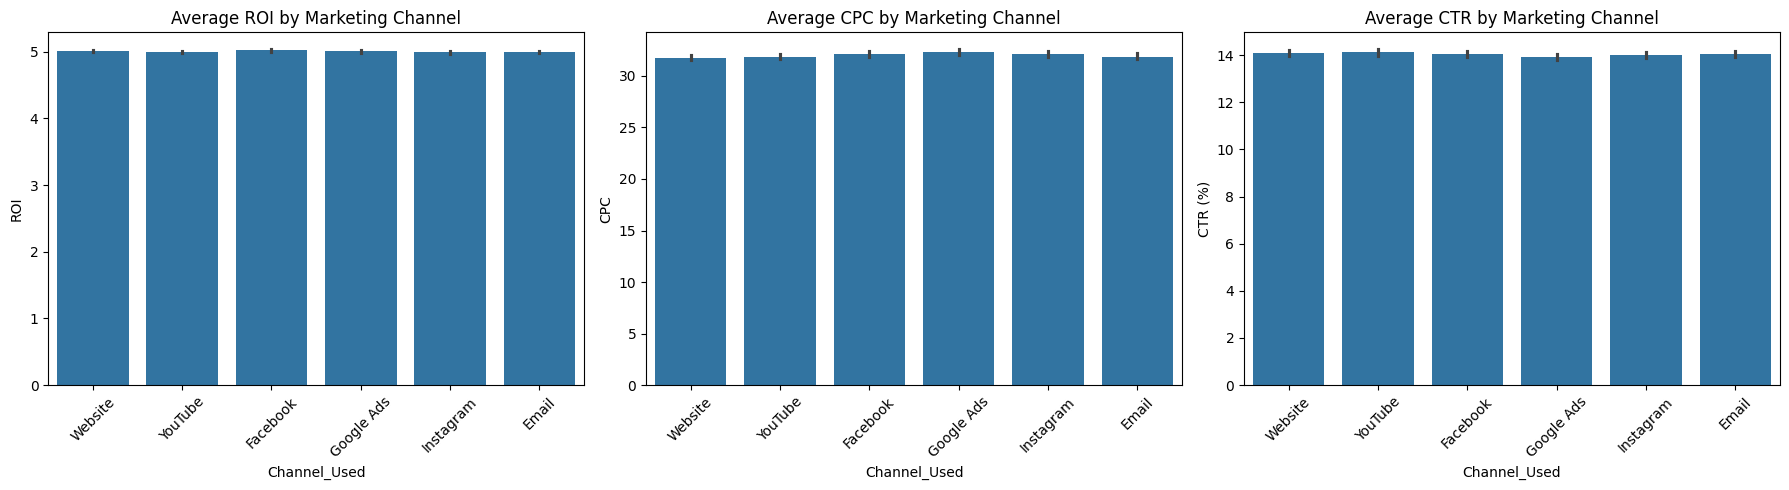

In [19]:
plt.figure(figsize=(18, 5))

# ROI by Marketing Channel
plt.subplot(1, 3, 1)
sns.barplot(data=df, x='Channel_Used', y='ROI', estimator='mean')
plt.title("Average ROI by Marketing Channel")
plt.xticks(rotation=45)

# CPC by Marketing Channel
plt.subplot(1, 3, 2)
sns.barplot(data=df, x='Channel_Used', y='CPC', estimator='mean')
plt.title("Average CPC by Marketing Channel")
plt.xticks(rotation=45)

# CTR by Marketing Channel
plt.subplot(1, 3, 3)
sns.barplot(data=df, x='Channel_Used', y='CTR (%)', estimator='mean')
plt.title("Average CTR by Marketing Channel")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


### Interpretation

The charts compare the average ROI, CPC, and CTR across different marketing channels.

- Marketing channels with **higher ROI** generate greater returns on investment.
- Channels with **lower CPC** are more cost-efficient in generating clicks.
- Channels with **higher CTR** are more effective at attracting user engagement.

These insights can help businesses allocate marketing budgets toward channels that deliver the best balance of profitability, cost efficiency, and audience engagement.

## 8. Correlation Analysis

Correlation analysis was conducted to examine the relationships between the numerical variables in the dataset.

A correlation heatmap provides a visual representation of how strongly variables are related to one another. Correlation coefficients range from **-1** to **1**:

- **1** indicates a perfect positive relationship.
- **0** indicates no relationship.
- **-1** indicates a perfect negative relationship.

Understanding these relationships helps identify variables that move together and provides insights into factors that may influence campaign performance.

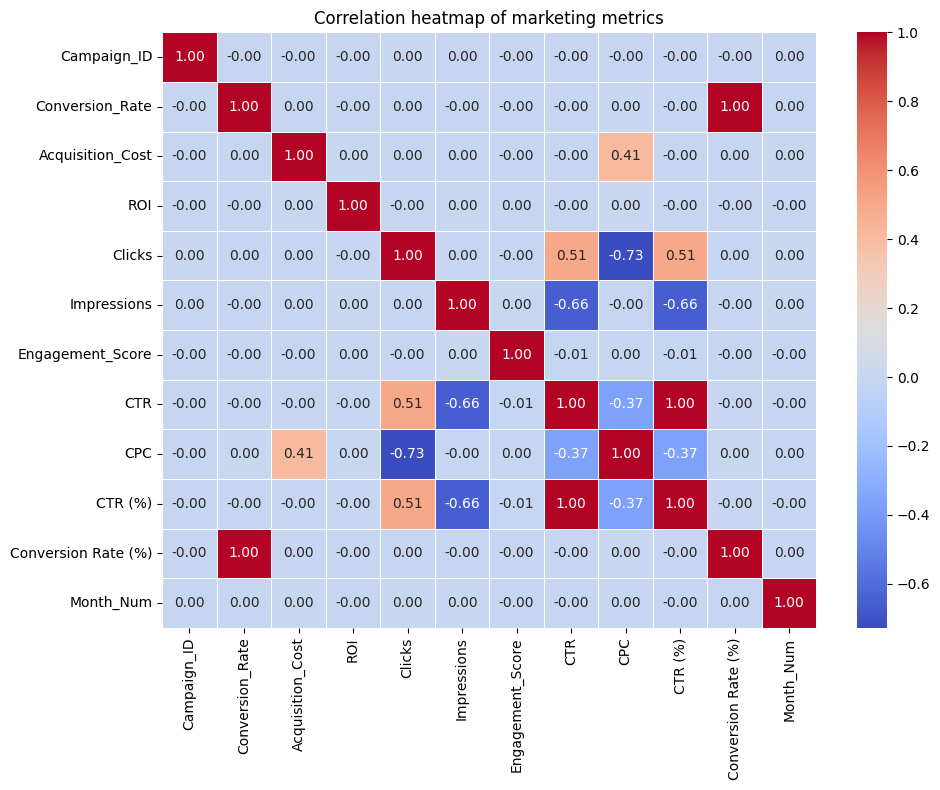

In [20]:
# Select only numerical columns
numerical_df = df.select_dtypes(include='number')

# Compute the correlation matrix
corr_matrix = numerical_df.corr()

# Plot the correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title("Correlation heatmap of marketing metrics")
plt.tight_layout()
plt.show()

### Interpretation

The correlation heatmap illustrates the relationships among the numerical variables in the marketing campaign dataset.

Key findings include:

- **Clicks and CTR (%)** have a **moderate positive correlation (0.51)**, indicating that campaigns with more clicks generally achieve higher click-through rates.
- **Impressions and CTR (%)** show a **moderate negative correlation (-0.66)**. This suggests that campaigns with very high impressions do not necessarily achieve high click-through rates, as impressions may increase faster than clicks.
- **Clicks and CPC** have a **strong negative correlation (-0.73)**, indicating that campaigns with more clicks tend to have a lower cost per click, making them more cost-efficient.
- **Acquisition Cost and CPC** have a **moderate positive correlation (0.41)**, suggesting that campaigns with higher acquisition costs generally incur higher costs per click.
- **ROI** has very weak or near-zero correlations with the other variables, indicating that campaign profitability is not strongly influenced by any single metric in this dataset.
- **Engagement Score** also shows little or no correlation with the other variables, suggesting that audience engagement is relatively independent of the measured campaign performance metrics.
- The perfect correlation (**1.00**) between **Conversion_Rate** and **Conversion Rate (%)** is expected because the percentage column was derived directly from the original conversion rate values.

### Business Insight

The correlation analysis suggests that improving campaign efficiency should focus on increasing clicks while controlling acquisition costs. Although higher clicks are associated with lower cost per click, they do not necessarily translate into higher ROI. This indicates that other factors, such as campaign quality, audience targeting, and conversion effectiveness, may play a more significant role in determining overall profitability.

## 9. ROI Distribution by Campaign Type

This visualization examines how the **Return on Investment (ROI)** varies across different campaign types.

A boxplot summarizes the distribution of ROI for each campaign type by displaying:

- The median (middle value)
- The interquartile range (middle 50% of the data)
- The minimum and maximum values within the whiskers
- Any potential outliers

This helps compare the consistency and profitability of different marketing campaign types.

/tmp/ipykernel_2009/3477391829.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


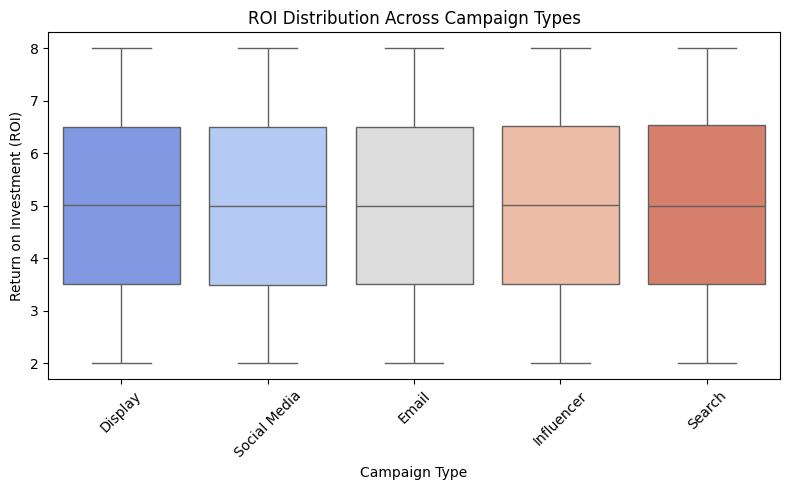

In [21]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Campaign_Type",
    y="ROI",
    palette="coolwarm"
)

plt.title("ROI Distribution Across Campaign Types")
plt.xlabel("Campaign Type")
plt.ylabel("Return on Investment (ROI)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Interpretation

The boxplot compares the distribution of **Return on Investment (ROI)** across different campaign types, including **Display, Social Media, Email, Influencer, and Search**.

Key observations include:

- The median ROI is approximately **5** for all campaign types, indicating similar average profitability.
- The interquartile ranges (IQRs) are nearly identical, suggesting that the variability in ROI is consistent across campaign types.
- The minimum and maximum ROI values range from approximately **2** to **8** for each campaign type, showing a similar spread of returns.
- No significant outliers are observed, indicating that the ROI values are relatively stable across all campaign types.

Overall, the results suggest that **campaign type alone does not have a significant impact on ROI** in this dataset, as all campaign types exhibit similar performance distributions.

### Business Insight

Since ROI is relatively consistent across all campaign types, organizations should not rely solely on campaign type when planning marketing strategies. Instead, they should consider other factors such as audience targeting, marketing channel selection, campaign content, and budget allocation, which may have a greater influence on campaign profitability.

## 10. Average ROI by Campaign Type and Marketing Channel

This heatmap examines the average Return on Investment (ROI) for each combination of **campaign type** and **marketing channel**.

By comparing these combinations, we can identify which marketing channels perform best for different campaign types and determine where marketing efforts may generate the highest returns.

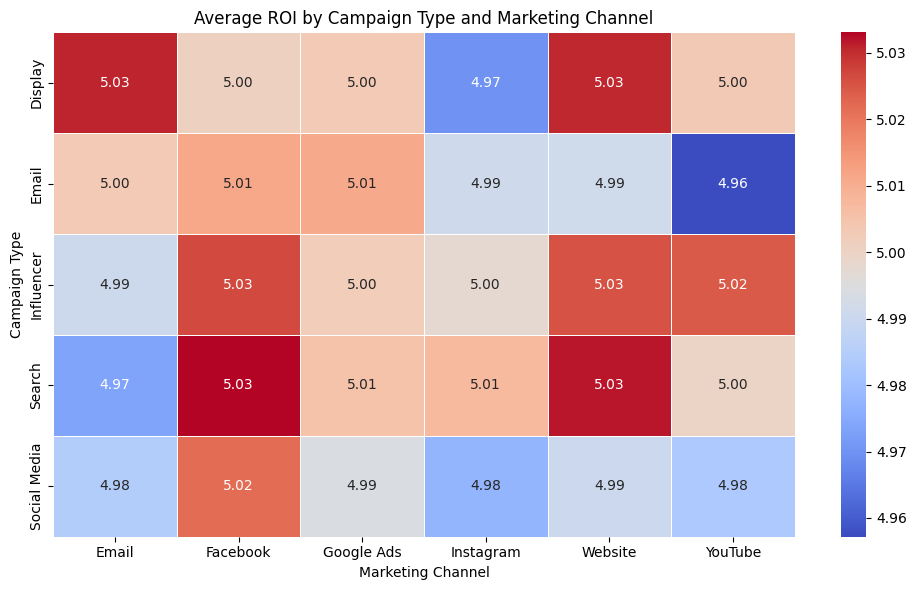

In [22]:
# Average ROI by Campaign Type and Marketing Channel
channel_campaign_metrics = (
    df.groupby(["Campaign_Type", "Channel_Used"])["ROI"]
      .mean()
      .unstack()
)

plt.figure(figsize=(10, 6))

sns.heatmap(
    channel_campaign_metrics,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Average ROI by Campaign Type and Marketing Channel")
plt.xlabel("Marketing Channel")
plt.ylabel("Campaign Type")

plt.tight_layout()
plt.show()

### Interpretation

The heatmap illustrates the average **Return on Investment (ROI)** for each combination of **Campaign Type** and **Marketing Channel**.

Key observations include:

- The average ROI is relatively consistent across all campaign type and marketing channel combinations, ranging from approximately **4.96 to 5.03**.
- **Display campaigns** achieved the highest average ROI (**5.03**) when delivered through **Email** and **Website** channels.
- **Influencer campaigns** also performed well on **Facebook** and **Website**, with an average ROI of approximately **5.03**.
- **Search campaigns** showed slightly higher ROI on **Facebook** and **Website** compared to the other channels.
- The lowest average ROI (**4.96**) was observed for **Email campaigns** delivered through **YouTube**, although the difference from the highest-performing combinations is very small.

Overall, the heatmap suggests that **marketing channel has only a modest impact on ROI within each campaign type**, as the differences in average ROI are minimal across the dataset.

### Business Insight

The analysis indicates that campaign performance is relatively stable regardless of the marketing channel used. Since ROI differences are small, organizations should base channel selection on additional factors such as target audience, campaign objectives, customer reach, and budget rather than expecting substantial differences in profitability from one channel alone.

Where small performance improvements are desired, combinations such as **Display–Website**, **Display–Email**, **Influencer–Website**, and **Search–Facebook** may be considered, as they recorded the highest average ROI in this dataset.

## 11. Campaign Performance by Campaign Type

This analysis compares the average performance of different campaign types using three important marketing metrics:

- **Return on Investment (ROI)** – measures campaign profitability.
- **Cost Per Click (CPC)** – measures the average cost incurred for each click.
- **Click-Through Rate (CTR)** – measures audience engagement by calculating the percentage of impressions that resulted in clicks.

Comparing these metrics helps identify which campaign types deliver the strongest overall marketing performance.

/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)


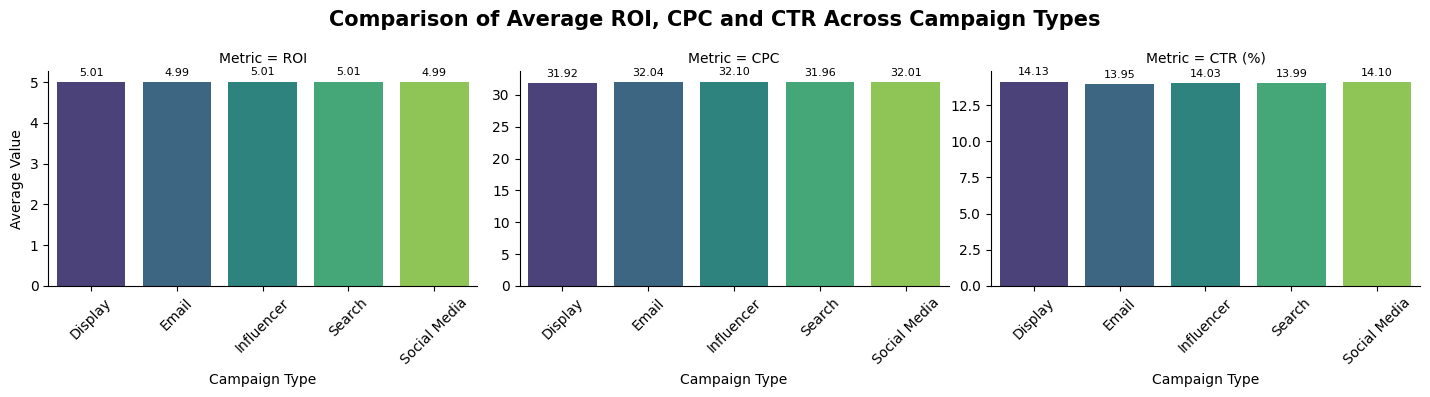

In [23]:
# Calculate average metrics by campaign type
campaign_stats = df.groupby("Campaign_Type").agg({
    "ROI": "mean",
    "CPC": "mean",
    "CTR (%)": "mean"
}).reset_index()

# Reshape the data for plotting
campaign_stats_melted = campaign_stats.melt(
    id_vars="Campaign_Type",
    var_name="Metric",
    value_name="Value"
)

# Create faceted bar charts
g = sns.FacetGrid(
    campaign_stats_melted,
    col="Metric",
    sharey=False,
    height=4,
    aspect=1.2
)

g.map_dataframe(
    sns.barplot,
    x="Campaign_Type",
    y="Value",
    palette="viridis"
)

# Improve labels
g.set_axis_labels("Campaign Type", "Average Value")

# Rotate x-axis labels
for ax in g.axes.flatten():
    ax.tick_params(axis='x', rotation=45)

# Add value labels
for ax in g.axes.flatten():
    for p in ax.patches:
        ax.annotate(
            f"{p.get_height():.2f}",
            (p.get_x() + p.get_width()/2, p.get_height()),
            ha="center",
            va="bottom",
            fontsize=8,
            xytext=(0,3),
            textcoords="offset points"
        )

g.fig.suptitle(
    "Comparison of Average ROI, CPC and CTR Across Campaign Types",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

### Interpretation

The figure compares the average **Return on Investment (ROI)**, **Cost Per Click (CPC)**, and **Click-Through Rate (CTR)** across the five campaign types.

Key observations include:

- The average **ROI** is very similar across all campaign types, ranging from **4.99 to 5.01**. Display, Influencer, and Search campaigns recorded the highest average ROI (5.01), while Email and Social Media campaigns had a slightly lower average ROI (4.99).
- The average **CPC** ranges from **31.92 to 32.10**, indicating only minor differences in the cost of generating clicks. Display campaigns have the lowest average CPC (31.92), making them the most cost-efficient, while Influencer campaigns have the highest average CPC (32.10).
- The average **CTR** ranges from **13.95% to 14.13%**. Display campaigns achieved the highest average CTR (14.13%), while Email campaigns recorded the lowest (13.95%).

Overall, the differences between campaign types are minimal, suggesting that all campaign types perform similarly in terms of profitability, cost efficiency, and audience engagement.

### Business Insight

The analysis indicates that no campaign type consistently outperforms the others across all three key performance metrics. While Display campaigns show a slight advantage with the highest average CTR and the lowest CPC, the differences are relatively small.

This suggests that selecting a campaign type should be based on business objectives, target audience, and marketing strategy rather than expecting substantial differences in ROI, CPC, or CTR alone.

# 12. Key Business Insights

1. **Campaign profitability remained remarkably consistent across all campaign types.**
   
   The average ROI ranged from **4.99 to 5.01**, indicating that Display, Search, Email, Influencer, and Social Media campaigns generated similar returns. This suggests that campaign type alone was not a major driver of profitability.

2. **Marketing channels delivered comparable returns on investment.**
   
   The ROI heatmap showed only slight variations across marketing channels. Although combinations such as **Display–Website**, **Display–Email**, and **Search–Facebook** recorded marginally higher ROI, the differences were too small to conclude that one channel consistently outperformed the others.

3. **Higher click volume was associated with lower acquisition cost per click.**
   
   The correlation analysis revealed a strong negative relationship (**-0.73**) between **Clicks** and **CPC**, suggesting that campaigns generating more clicks tended to do so more cost-effectively.

4. **Increasing impressions alone did not improve campaign engagement.**
   
   A moderate negative correlation (**-0.66**) was observed between **Impressions** and **CTR**, indicating that exposing advertisements to more users does not necessarily translate into higher engagement.

5. **Campaign profitability was influenced by multiple factors rather than a single performance metric.**
   
   ROI showed little correlation with clicks, impressions, engagement score, or acquisition cost. This suggests that profitability is likely determined by a combination of campaign quality, audience targeting, messaging, and conversion effectiveness.

6. **Performance variability across campaign types was minimal.**
   
   The boxplots showed similar medians, interquartile ranges, and overall distributions of ROI for every campaign type, indicating consistent campaign performance throughout the dataset.

# 13. Recommendations

Based on the analysis, the following recommendations are proposed:

### 1. Prioritize campaign quality over campaign type.

Since ROI remained consistent across all campaign types, marketers should focus on improving creative content, audience segmentation, and messaging rather than assuming one campaign type will automatically generate better returns.

### 2. Improve click quality instead of simply increasing impressions.

The negative relationship between impressions and CTR suggests that expanding reach alone may reduce engagement efficiency. Future campaigns should target more relevant audiences to increase the likelihood of meaningful interactions.

### 3. Monitor Cost Per Click alongside click volume.

The analysis showed that campaigns with higher click volumes generally achieved lower CPC. Optimizing advertisements to encourage more clicks may improve cost efficiency without necessarily increasing advertising spend.

### 4. Test marketing channel combinations continuously.

Although differences in ROI across channels were small, combinations such as Website, Facebook, and Email showed slightly stronger performance for certain campaign types. Continuous A/B testing should be conducted to validate whether these small advantages persist in real-world campaigns.

### 5. Incorporate additional business metrics in future analyses.

Future evaluations should include revenue generated, customer lifetime value (CLV), conversion value, and customer acquisition cost (CAC). These metrics would provide a more comprehensive understanding of campaign effectiveness beyond clicks and impressions.

# 14. Conclusion

This project explored the performance of marketing campaigns using Python for data cleaning, feature engineering, exploratory data analysis, and visualization.

The analysis found that campaign performance was generally consistent across different campaign types and marketing channels. While slight variations existed, no campaign type or marketing channel demonstrated a substantial advantage in terms of return on investment. The correlation analysis further showed that increasing clicks tended to reduce cost per click, whereas increasing impressions alone did not necessarily improve engagement.

Overall, the findings suggest that successful marketing campaigns depend less on selecting a specific campaign type or channel and more on optimizing targeting, campaign quality, and audience engagement. This analysis demonstrates how data-driven insights can support marketing decision-making and highlights the importance of combining multiple performance indicators when evaluating campaign success.

# 15. Limitations

- The dataset used in this analysis is synthetic and exhibits very little variation across campaign types and marketing channels.
- As a result, the findings should be interpreted as a demonstration of analytical techniques rather than definitive evidence of real-world marketing performance.
- Future analyses using real campaign data would likely reveal stronger relationships and more actionable business insights.